In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
perf = pd.read_csv("../data/processed/scheme_performance_clean.csv")
txn = pd.read_csv("../data/processed/investor_transactions_clean.csv")
portfolio = pd.read_csv("../data/processed/portfolio_holdings_clean.csv")

In [3]:
nav.head()
perf.head()
txn.head()
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [5]:
var_report = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 30:
        continue

    var95 = np.percentile(returns,5)

    cvar95 = returns[returns <= var95].mean()

    var_report.append([
        code,
        var95,
        cvar95
    ])

var_df = pd.DataFrame(
    var_report,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

In [6]:
var_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [7]:
returns = nav.copy()

rolling_sharpe = (
    returns.groupby("amfi_code")["daily_return"]
    .rolling(90)
    .mean()
    /
    returns.groupby("amfi_code")["daily_return"]
    .rolling(90)
    .std()
) * np.sqrt(252)

rolling_sharpe = rolling_sharpe.reset_index()
rolling_sharpe.columns = [
    "amfi_code",
    "index",
    "rolling_sharpe"
]

In [8]:
top5 = (
    perf.sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(5)["amfi_code"]
    .tolist()
)

top5

[120507, 120844, 101208, 100025, 119120]

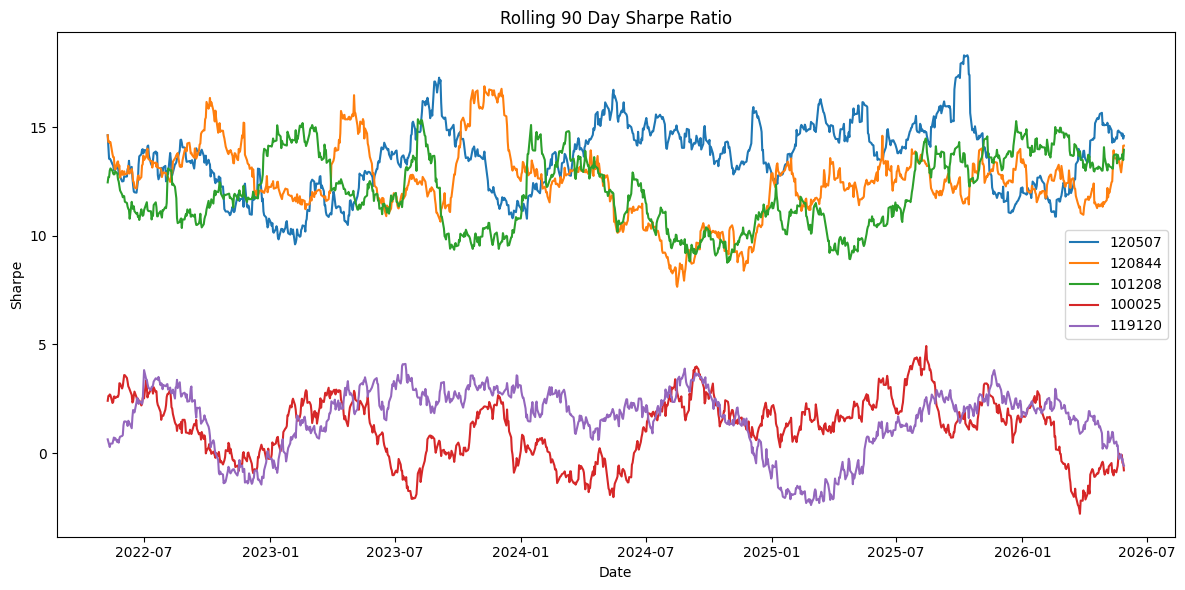

In [9]:
plt.figure(figsize=(12,6))

for fund in top5:

    temp = nav[nav["amfi_code"] == fund]

    rs = rolling_sharpe[
        rolling_sharpe["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"].iloc[:len(rs)],
        rs["rolling_sharpe"],
        label=str(fund)
    )

plt.legend()
plt.title("Rolling 90 Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe")

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

# Investor Cohort Analysis

In [10]:
import pandas as pd

investor = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

In [11]:
first_txn = (
    investor.groupby("investor_id")
    ["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [12]:
investor = investor.merge(
    first_txn[
        ["investor_id","cohort_year"]
    ],
    on="investor_id",
    how="left"
)

In [13]:
cohort_summary = (
    investor.groupby("cohort_year")
    .agg(
        avg_sip_amount=(
            "amount_inr",
            "mean"
        ),
        total_invested=(
            "amount_inr",
            "sum"
        )
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [14]:
top_fund = (
    investor.groupby(
        ["cohort_year","amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund.sort_values(
        ["cohort_year","count"],
        ascending=False
    )
    .groupby("cohort_year")
    .head(1)
)

top_fund

,cohort_year,amfi_code,count
62,2025,119599,12
35,2024,148568,874


In [15]:
cohort_summary.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

top_fund.to_csv(
    "../reports/cohort_top_fund.csv",
    index=False
)

# SIP Continuity Analysis

In [16]:
sip = investor[
    investor["transaction_type"]
    .str.lower() == "sip"
].copy()

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,Sip,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,Sip,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [17]:
sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

In [18]:
sip["gap_days"] = (
    sip.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

In [19]:
sip_gap = (
    sip.groupby("investor_id")
    .agg(
        sip_count=(
            "transaction_date",
            "count"
        ),
        avg_gap_days=(
            "gap_days",
            "mean"
        )
    )
    .reset_index()
)

sip_gap.head()

,investor_id,sip_count,avg_gap_days
0,INV000001,2,76.0
1,INV000002,3,207.0
2,INV000003,2,238.0
3,INV000004,6,85.4
4,INV000005,3,14.0


In [20]:
sip_gap = sip_gap[
    sip_gap["sip_count"] >= 6
]

In [21]:
sip_gap["status"] = np.where(
    sip_gap["avg_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

sip_gap.head()

,investor_id,sip_count,avg_gap_days,status
3,INV000004,6,85.400000,At Risk
7,INV000008,6,70.400000,At Risk
9,INV000010,6,64.800000,At Risk
10,INV000011,7,40.166667,At Risk
11,INV000012,8,57.000000,At Risk


In [22]:
sip_gap.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

In [23]:
holdings = pd.read_csv(
    "../data/processed/portfolio_holdings_clean.csv"
)

holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [24]:
hhi_df = (
    holdings.groupby("amfi_code")["weight_pct"]
    .apply(lambda x: ((x / 100) ** 2).sum())
    .reset_index()
)

hhi_df.columns = [
    "amfi_code",
    "hhi"
]

hhi_df = hhi_df.sort_values(
    "hhi",
    ascending=False
)

hhi_df.head()

,amfi_code,hhi
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


In [25]:
hhi_df.to_csv(
    "../reports/hhi_concentration.csv",
    index=False
)

# Advanced Insights

### Insight 1
Funds with the highest VaR and CVaR exhibit significantly larger downside risk and are more vulnerable during volatile market conditions.

### Insight 2
Rolling 90-Day Sharpe ratios indicate that selected funds maintained relatively stable risk-adjusted returns through most market cycles.

### Insight 3
The 2024 investor cohort contributed the highest overall investment amount and showed the strongest participation in SIP investments.

### Insight 4
A significant number of SIP investors were classified as At Risk due to average transaction gaps exceeding 35 days, indicating potential future churn.

### Insight 5
Funds with higher HHI values demonstrate greater portfolio concentration, while lower HHI funds provide better diversification across sectors.